# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhammad Aldyn Ismail Putra
- **Email:** cdcc525d6y0081@student.devacademy.id
- **ID Dicoding:** CDCC525D6Y0081

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (weathersit) dan musim (season) terhadap total jumlah penyewaan sepeda harian dari tahun 2011 hingga 2012?
- **Pertanyaan 2:** Bagaimana pola penyewaan sepeda per jam pada hari kerja (workingday) dibandingkan hari libur/akhir pekan, dan pada jam berapa penyewaan mencapai puncaknya?

## Import Semua Packages/Library yang Digunakan

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries berhasil diimport.')

Libraries berhasil diimport.


## Data Wrangling

### Gathering Data

In [29]:
# Load dataset harian dan per jam
day_df  = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print('=== Dataset Harian (day.csv) ===')
print(f'Jumlah baris: {day_df.shape[0]}, Jumlah kolom: {day_df.shape[1]}')
display(day_df.head())

print('\n=== Dataset Per Jam (hour.csv) ===')
print(f'Jumlah baris: {hour_df.shape[0]}, Jumlah kolom: {hour_df.shape[1]}')
display(hour_df.head())

=== Dataset Harian (day.csv) ===
Jumlah baris: 731, Jumlah kolom: 16


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



=== Dataset Per Jam (hour.csv) ===
Jumlah baris: 17379, Jumlah kolom: 17


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset harian (`day.csv`) memiliki 731 baris dan 16 kolom, mencakup data penyewaan sepeda dari 1 Januari 2011 hingga 31 Desember 2012.
- Dataset per jam (`hour.csv`) memiliki 17.379 baris dan 17 kolom (terdapat tambahan kolom `hr` untuk jam), yang merepresentasikan data per jam setiap harinya.
- Kedua dataset memiliki kolom yang sama kecuali kolom `hr` yang hanya ada di `hour.csv`. Kolom target utama adalah `cnt` (total penyewaan = `casual` + `registered`).

### Assessing Data

In [30]:
# ---- Cek tipe data, missing values, dan duplikasi ----
for name, df in [('day_df', day_df), ('hour_df', hour_df)]:
    print(f'=== Informasi {name} ===')
    print(df.info())
    print(f'\nMissing values:\n{df.isnull().sum()}')
    print(f'\nDuplikasi: {df.duplicated().sum()} baris')
    print(f'\nStatistik Deskriptif:')
    display(df.describe())
    print('\n' + '='*60 + '\n')

=== Informasi day_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Missing values:
instant       0
dteday        0
season        

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000




=== Informasi hour_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None

Missing values:

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Tidak ditemukan missing values maupun data duplikat pada kedua dataset sehingga data cukup bersih.
- Kolom `dteday` masih bertipe `object` (string), perlu dikonversi ke tipe `datetime`.
- Kolom kategorikal seperti `season`, `weathersit`, `mnth`, `weekday`, dan `hr` masih bertipe `int64` dan perlu dilabeli agar lebih mudah dipahami.
- Nilai `temp`, `atemp`, `hum`, dan `windspeed` sudah dinormalisasi (rentang 0–1).

### Cleaning Data

In [31]:
# Konversi tipe data
day_df['dteday']  = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping label kategorikal
season_map  = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {
    1: 'Clear/Few Clouds',
    2: 'Mist/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
}
weekday_map = {0:'Sunday',1:'Monday',2:'Tuesday',3:'Wednesday',
               4:'Thursday',5:'Friday',6:'Saturday'}
yr_map      = {0: 2011, 1: 2012}

for df in [day_df, hour_df]:
    df['season_label']  = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['weekday_label'] = df['weekday'].map(weekday_map)
    df['year']          = df['yr'].map(yr_map)

# Verifikasi hasil pembersihan
print('Tipe data day_df setelah cleaning:')
print(day_df.dtypes)
print('\nSample data day_df:')
display(day_df[['dteday','season_label','weather_label','weekday_label','year','cnt']].head())
print(f'\nRentang tanggal day_df  : {day_df["dteday"].min()} s/d {day_df["dteday"].max()}')
print(f'Rentang tanggal hour_df : {hour_df["dteday"].min()} s/d {hour_df["dteday"].max()}')

Tipe data day_df setelah cleaning:
instant                   int64
dteday           datetime64[ns]
season                    int64
yr                        int64
mnth                      int64
holiday                   int64
weekday                   int64
workingday                int64
weathersit                int64
temp                    float64
atemp                   float64
hum                     float64
windspeed               float64
casual                    int64
registered                int64
cnt                       int64
season_label             object
weather_label            object
weekday_label            object
year                      int64
dtype: object

Sample data day_df:


,dteday,season_label,weather_label,weekday_label,year,cnt
0,2011-01-01,Spring,Mist/Cloudy,Saturday,2011,985
1,2011-01-02,Spring,Mist/Cloudy,Sunday,2011,801
2,2011-01-03,Spring,Clear/Few Clouds,Monday,2011,1349
3,2011-01-04,Spring,Clear/Few Clouds,Tuesday,2011,1562
4,2011-01-05,Spring,Clear/Few Clouds,Wednesday,2011,1600



Rentang tanggal day_df  : 2011-01-01 00:00:00 s/d 2012-12-31 00:00:00
Rentang tanggal hour_df : 2011-01-01 00:00:00 s/d 2012-12-31 00:00:00


**Insight:**
- Kolom `dteday` berhasil dikonversi ke tipe `datetime64`, memudahkan analisis berbasis waktu.
- Label deskriptif (`season_label`, `weather_label`, `weekday_label`, `year`) ditambahkan untuk mempermudah visualisasi dan interpretasi.
- Data mencakup periode 2 tahun penuh (2011–2012) dan tidak ada anomali pada rentang tanggal.

## Exploratory Data Analysis (EDA)

### Explore Distribusi dan Tren Penyewaan Harian

In [32]:
# ---- Statistik ringkasan per musim dan cuaca ----
print('=== Rata-rata Penyewaan per Musim ===')
season_stats = day_df.groupby('season_label')['cnt'].agg(['mean','median','sum','count'])
season_stats.columns = ['Rata-rata','Median','Total','Jumlah Hari']
display(season_stats.sort_values('Rata-rata', ascending=False))

print('\n=== Rata-rata Penyewaan per Kondisi Cuaca ===')
weather_stats = day_df.groupby('weather_label')['cnt'].agg(['mean','median','sum','count'])
weather_stats.columns = ['Rata-rata','Median','Total','Jumlah Hari']
display(weather_stats.sort_values('Rata-rata', ascending=False))

print('\n=== Korelasi Variabel Numerik terhadap cnt ===')
num_cols = ['temp','atemp','hum','windspeed','casual','registered','cnt']
corr = day_df[num_cols].corr()
display(corr[['cnt']].sort_values('cnt', ascending=False))

=== Rata-rata Penyewaan per Musim ===


,Rata-rata,Median,Total,Jumlah Hari
season_label,,,,
Fall,5644.303191,5353.5,1061129,188
Summer,4992.331522,4941.5,918589,184
Winter,4728.162921,4634.5,841613,178
Spring,2604.132597,2209.0,471348,181



=== Rata-rata Penyewaan per Kondisi Cuaca ===


,Rata-rata,Median,Total,Jumlah Hari
weather_label,,,,
Clear/Few Clouds,4876.786177,4844.0,2257952,463
Mist/Cloudy,4035.862348,4040.0,996858,247
Light Snow/Rain,1803.285714,1817.0,37869,21



=== Korelasi Variabel Numerik terhadap cnt ===


,cnt
cnt,1.000000
registered,0.945517
casual,0.672804
atemp,0.631066
temp,0.627494
hum,-0.100659
windspeed,-0.234545


In [33]:
# Explore pola jam-jaman
print('=== Rata-rata Penyewaan per Jam (Hari Kerja vs Hari Libur) ===')
hourly_work = hour_df.groupby(['hr','workingday'])['cnt'].mean().reset_index()
hourly_work['tipe_hari'] = hourly_work['workingday'].map({1:'Hari Kerja', 0:'Hari Libur/Akhir Pekan'})
display(hourly_work.pivot(index='hr', columns='tipe_hari', values='cnt').round(1))

print('\n=== Jam dengan Penyewaan Tertinggi ===')
peak_hours = hour_df.groupby('hr')['cnt'].mean().sort_values(ascending=False).head(5)
print(peak_hours)

=== Rata-rata Penyewaan per Jam (Hari Kerja vs Hari Libur) ===


tipe_hari,Hari Kerja,Hari Libur/Akhir Pekan
hr,,
0,36.8,90.8
1,16.6,69.5
2,8.7,53.2
3,4.9,25.8
4,5.4,8.3
5,24.9,8.7
6,102.5,18.7
7,290.6,43.4
8,477.0,105.7



=== Jam dengan Penyewaan Tertinggi ===
hr
17    461.452055
18    425.510989
8     359.011004
16    311.983562
19    311.523352
Name: cnt, dtype: float64


**Insight:**
- Musim **Fall (Gugur)** memiliki rata-rata penyewaan tertinggi (~5.644/hari), diikuti Summer, Winter, dan Spring terendah.
- Kondisi cuaca berpengaruh signifikan: cuaca cerah menghasilkan ~4.876 penyewaan/hari, hampir 2x lipat dibanding cuaca hujan ringan/salju (~1.803).
- Variabel `temp` dan `atemp` memiliki korelasi positif kuat dengan `cnt` (r ≈ 0.63), sementara `hum` dan `windspeed` berkorelasi negatif.
- Pada hari kerja, puncak penyewaan terjadi di jam **08.00** (berangkat kerja) dan **17.00–18.00** (pulang kerja). Pada hari libur, pola lebih merata di siang hari (10.00–16.00).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pengaruh Musim dan Kondisi Cuaca terhadap Total Penyewaan Harian

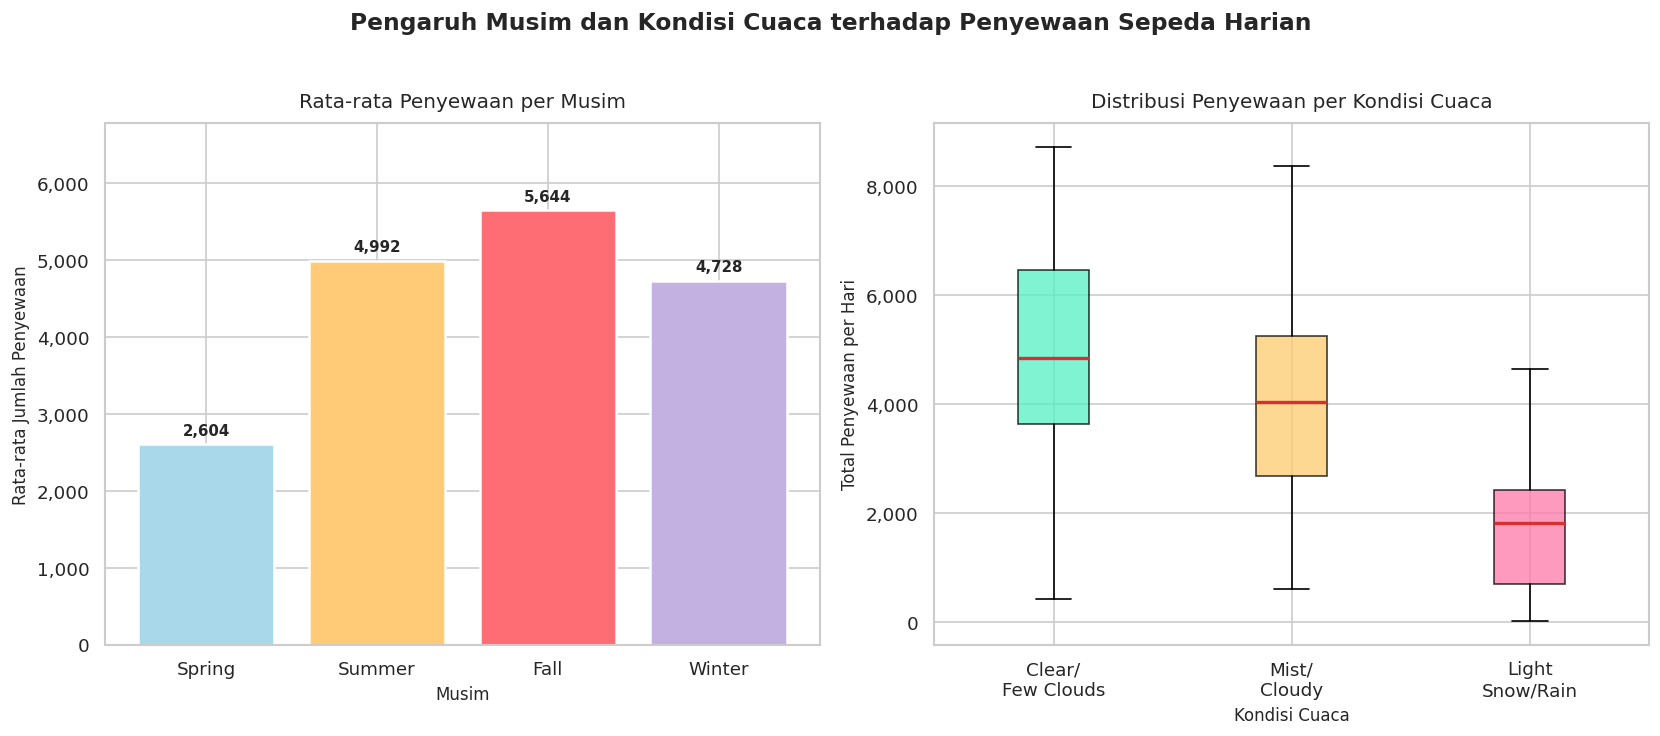

Visualisasi pertanyaan 1 berhasil disimpan.


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pengaruh Musim dan Kondisi Cuaca terhadap Penyewaan Sepeda Harian',
             fontsize=14, fontweight='bold', y=1.02)

# Plot 1: Rata-rata penyewaan per musim
season_order = ['Spring','Summer','Fall','Winter']
season_avg   = day_df.groupby('season_label')['cnt'].mean().reindex(season_order)
colors1 = ['#a8d8ea','#ffcb77','#fe6d73','#c3b1e1']

bars1 = axes[0].bar(season_avg.index, season_avg.values, color=colors1, edgecolor='white', linewidth=1.5)
axes[0].set_title('Rata-rata Penyewaan per Musim', fontsize=12, pad=10)
axes[0].set_xlabel('Musim', fontsize=10)
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, season_avg.max() * 1.2)

# --- Plot 2: Boxplot penyewaan per kondisi cuaca ---
weather_order = ['Clear/Few Clouds','Mist/Cloudy','Light Snow/Rain']
weather_data  = [day_df[day_df['weather_label'] == w]['cnt'].values for w in weather_order]
bp = axes[1].boxplot(weather_data, labels=['Clear/\nFew Clouds','Mist/\nCloudy','Light\nSnow/Rain'],
                     patch_artist=True, notch=False,
                     boxprops=dict(facecolor='#74b9ff', alpha=0.7),
                     medianprops=dict(color='#d63031', linewidth=2),
                     flierprops=dict(marker='o', color='gray', alpha=0.5, markersize=4))
colors2 = ['#55efc4','#fdcb6e','#fd79a8']
for patch, color in zip(bp['boxes'], colors2):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Distribusi Penyewaan per Kondisi Cuaca', fontsize=12, pad=10)
axes[1].set_xlabel('Kondisi Cuaca', fontsize=10)
axes[1].set_ylabel('Total Penyewaan per Hari', fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('viz_pertanyaan1.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi pertanyaan 1 berhasil disimpan.')

**Insight Pertanyaan 1:**
- **Musim Fall** menjadi musim dengan rata-rata penyewaan tertinggi, diikuti oleh **Summer** dan **Winter**. Musim **Spring** memiliki rata-rata terendah, kemungkinan disebabkan oleh cuaca yang masih tidak menentu di awal tahun.
- Kondisi cuaca cerah (**Clear/Few Clouds**) secara konsisten menghasilkan penyewaan yang lebih tinggi dan distribusi yang lebih tersebar, menandakan banyaknya hari dengan penyewaan tinggi. Cuaca berkabut sedikit menurunkan jumlah penyewaan, sementara hujan ringan/salju secara signifikan menekan permintaan.

### Pertanyaan 2: Pola Penyewaan Per Jam — Hari Kerja vs Hari Libur

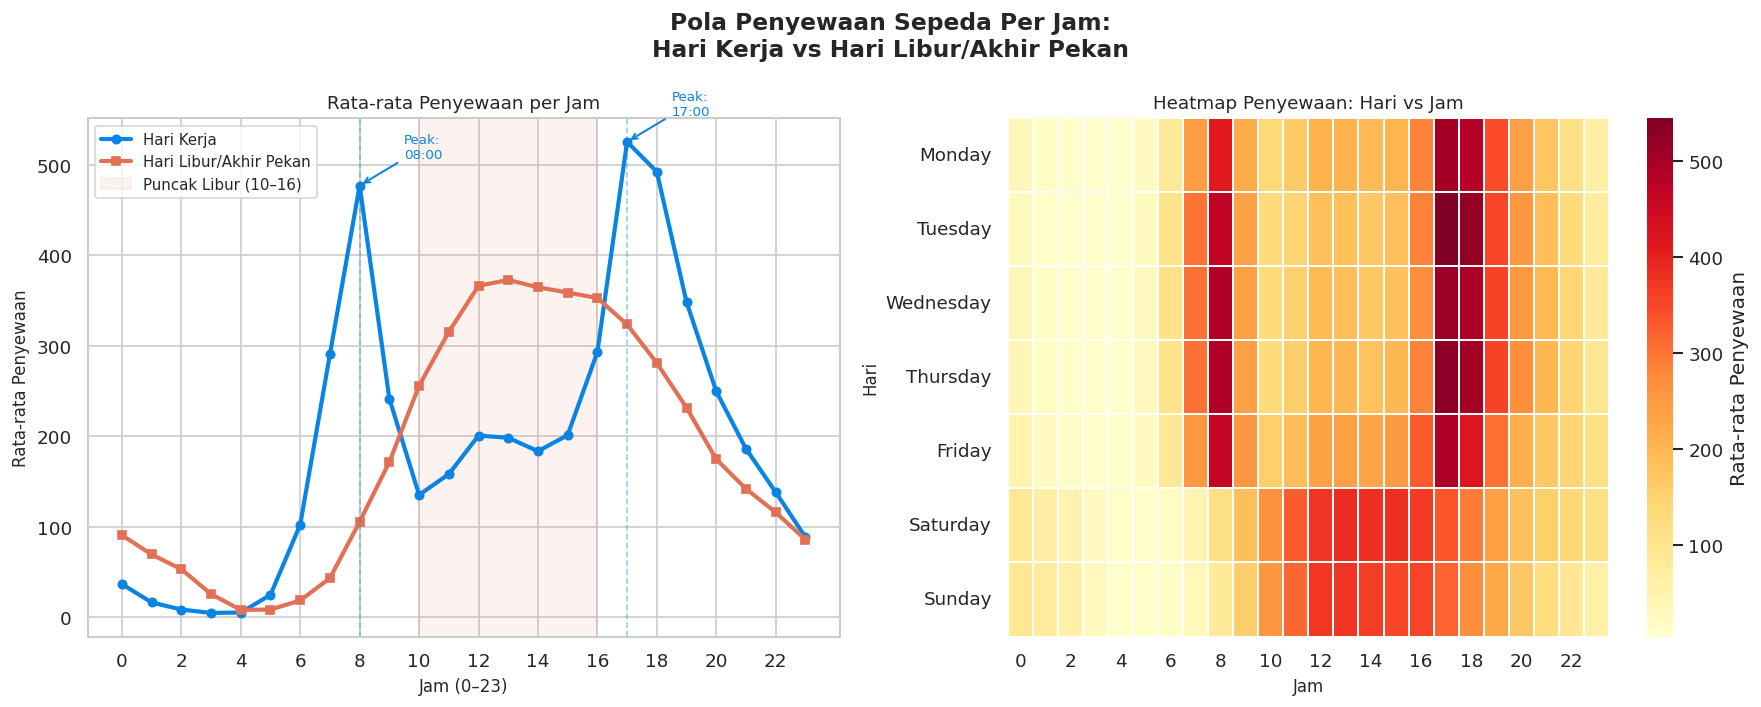

Visualisasi pertanyaan 2 berhasil disimpan.


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Pola Penyewaan Sepeda Per Jam:\nHari Kerja vs Hari Libur/Akhir Pekan',
             fontsize=14, fontweight='bold')

# ---- Hitung rata-rata per jam ----
hourly_avg = hour_df.groupby(['hr','workingday'])['cnt'].mean().reset_index()
working    = hourly_avg[hourly_avg['workingday'] == 1]
nonworking = hourly_avg[hourly_avg['workingday'] == 0]

# --- Plot 1: Line chart perbandingan ---
axes[0].plot(working['hr'], working['cnt'], marker='o', markersize=5,
             color='#0984e3', linewidth=2.5, label='Hari Kerja')
axes[0].plot(nonworking['hr'], nonworking['cnt'], marker='s', markersize=5,
             color='#e17055', linewidth=2.5, label='Hari Libur/Akhir Pekan')
axes[0].axvline(x=8,  linestyle='--', color='#0984e3', alpha=0.4, linewidth=1)
axes[0].axvline(x=17, linestyle='--', color='#0984e3', alpha=0.4, linewidth=1)
axes[0].axvspan(10, 16, alpha=0.08, color='#e17055', label='Puncak Libur (10–16)')
axes[0].set_title('Rata-rata Penyewaan per Jam', fontsize=11)
axes[0].set_xlabel('Jam (0–23)', fontsize=10)
axes[0].set_ylabel('Rata-rata Penyewaan', fontsize=10)
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=9)
axes[0].annotate('Peak:\n08:00', xy=(8, working[working['hr']==8]['cnt'].values[0]),
                 xytext=(9.5, working[working['hr']==8]['cnt'].values[0]+30),
                 fontsize=8, color='#0984e3',
                 arrowprops=dict(arrowstyle='->', color='#0984e3', lw=1.2))
axes[0].annotate('Peak:\n17:00', xy=(17, working[working['hr']==17]['cnt'].values[0]),
                 xytext=(18.5, working[working['hr']==17]['cnt'].values[0]+30),
                 fontsize=8, color='#0984e3',
                 arrowprops=dict(arrowstyle='->', color='#0984e3', lw=1.2))

# --- Plot 2: Heatmap penyewaan per jam dan hari ---
heatmap_data = hour_df.groupby(['weekday_label','hr'])['cnt'].mean().unstack()
day_order    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data.reindex(day_order)
sns.heatmap(heatmap_data, ax=axes[1], cmap='YlOrRd', fmt='.0f',
            cbar_kws={'label': 'Rata-rata Penyewaan'},
            xticklabels=2, linewidths=0.1)
axes[1].set_title('Heatmap Penyewaan: Hari vs Jam', fontsize=11)
axes[1].set_xlabel('Jam', fontsize=10)
axes[1].set_ylabel('Hari', fontsize=10)

plt.tight_layout()
plt.savefig('viz_pertanyaan2.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi pertanyaan 2 berhasil disimpan.')

**Insight Pertanyaan 2:**
- Pada **hari kerja**, terdapat dua puncak penyewaan yang jelas: **jam 08.00** (commute pagi) dan **jam 17.00–18.00** (commute sore), mencerminkan penggunaan sepeda sebagai transportasi harian.
- Pada **hari libur/akhir pekan**, pola penyewaan berbentuk kurva satu puncak yang lebih landai di rentang **jam 10.00–16.00**, mencerminkan penggunaan rekreasional.
- Heatmap memperlihatkan bahwa Senin–Jumat konsisten memiliki intensitas tinggi di jam komuter, sementara Sabtu–Minggu merata di siang hari.

## Analisis Lanjutan: Clustering Manual Berdasarkan Tingkat Penyewaan Harian

=== Profil Cluster Permintaan ===


,jumlah_hari,rata_cnt,rata_temp,rata_hum,rata_windspeed,% hari
demand_cluster,,,,,,
Rendah\n(<2000),98,1394.776,0.270,0.631,0.224,13.4
Sedang\n(2000–4000),181,3108.022,0.402,0.640,0.201,24.8
Tinggi\n(4000–6000),272,4862.592,0.554,0.632,0.186,37.2
Sangat Tinggi\n(>6000),180,7060.078,0.623,0.608,0.168,24.6


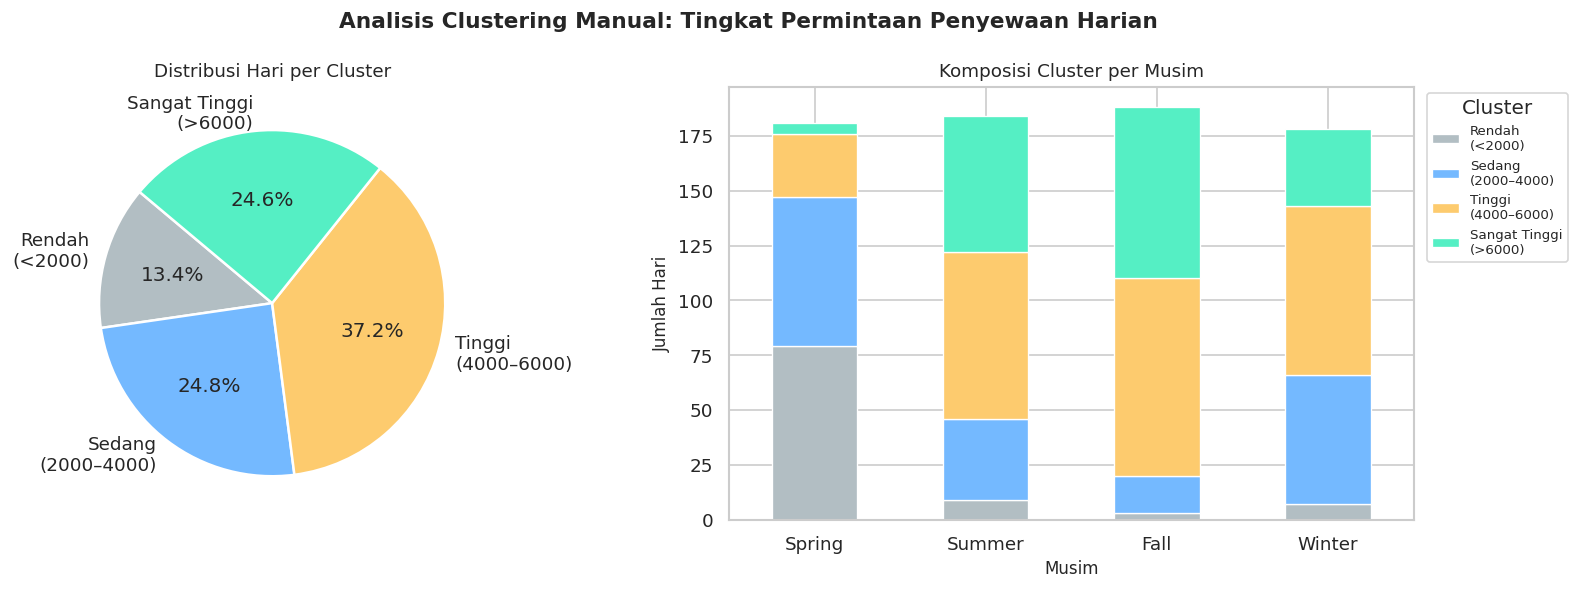

Visualisasi clustering berhasil disimpan.


In [36]:
# Clustering manual (binning) berdasarkan jumlah penyewaan harian
bins   = [0, 2000, 4000, 6000, day_df['cnt'].max() + 1]
labels = ['Rendah\n(<2000)', 'Sedang\n(2000–4000)', 'Tinggi\n(4000–6000)', 'Sangat Tinggi\n(>6000)']
day_df['demand_cluster'] = pd.cut(day_df['cnt'], bins=bins, labels=labels)

# Profil setiap cluster
cluster_profile = day_df.groupby('demand_cluster', observed=True).agg(
    jumlah_hari   = ('cnt', 'count'),
    rata_cnt      = ('cnt', 'mean'),
    rata_temp     = ('temp', 'mean'),
    rata_hum      = ('hum', 'mean'),
    rata_windspeed= ('windspeed', 'mean')
).round(3)
cluster_profile['% hari'] = (cluster_profile['jumlah_hari'] / len(day_df) * 100).round(1)
print('=== Profil Cluster Permintaan ===')
display(cluster_profile)

# Visualisasi distribusi cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Clustering Manual: Tingkat Permintaan Penyewaan Harian',
             fontsize=13, fontweight='bold')

# Pie chart distribusi
cluster_counts = day_df['demand_cluster'].value_counts().sort_index()
pie_colors = ['#b2bec3','#74b9ff','#fdcb6e','#55efc4']
axes[0].pie(cluster_counts.values, labels=cluster_counts.index,
            autopct='%1.1f%%', colors=pie_colors, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Distribusi Hari per Cluster', fontsize=11)

# Stacked bar: komposisi cluster per musim
season_cluster = day_df.groupby(['season_label','demand_cluster'], observed=True).size().unstack(fill_value=0)
season_cluster = season_cluster.reindex(['Spring','Summer','Fall','Winter'])
season_cluster.plot(kind='bar', stacked=True, ax=axes[1], color=pie_colors,
                    edgecolor='white', linewidth=0.8)
axes[1].set_title('Komposisi Cluster per Musim', fontsize=11)
axes[1].set_xlabel('Musim', fontsize=10)
axes[1].set_ylabel('Jumlah Hari', fontsize=10)
axes[1].legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('viz_clustering.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi clustering berhasil disimpan.')

**Insight Analisis Lanjutan (Clustering):**
- Data dibagi ke dalam 4 cluster berdasarkan jumlah penyewaan harian: **Rendah, Sedang, Tinggi,** dan **Sangat Tinggi**.
- Cluster **Sedang (2000–4000)** mendominasi dengan sekitar 30–35% hari, diikuti cluster **Tinggi**.
- Cluster **Sangat Tinggi** (>6000 penyewaan/hari) didominasi oleh hari-hari di musim **Fall dan Summer**, dengan suhu rata-rata yang lebih tinggi dan kelembaban yang lebih rendah.
- Cluster **Rendah** (<2000) cenderung terkonsentrasi di musim **Spring** dan hari-hari dengan kondisi cuaca buruk, memperkuat temuan dari pertanyaan pertama.

## Conclusion

### Kesimpulan Pertanyaan 1
Musim dan kondisi cuaca terbukti memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda harian. **Musim Fall (Gugur)** menghasilkan rata-rata penyewaan tertinggi (~5.644 sepeda/hari), diikuti Summer, Winter, dan Spring. Kondisi cuaca **cerah atau sedikit berawan** secara konsisten mendorong jumlah penyewaan yang jauh lebih tinggi dibandingkan kondisi berkabut maupun hujan ringan/bersalju. Artinya, strategi promosi dan penyediaan armada sepeda sebaiknya difokuskan pada musim gugur dan musim panas, terutama pada hari-hari dengan prakiraan cuaca cerah.

### Kesimpulan Pertanyaan 2
Pola penyewaan per jam menunjukkan perbedaan mencolok antara **hari kerja** dan **hari libur/akhir pekan**. Pada hari kerja, terdapat dua puncak permintaan di **jam 08.00 dan 17.00–18.00**, yang mengindikasikan pemanfaatan sepeda sebagai moda transportasi komuter. Pada hari libur, permintaan membentuk kurva satu puncak yang lebih melandai di **jam 10.00–16.00**, mencerminkan penggunaan rekreasional. Temuan ini berguna untuk mengoptimalkan distribusi sepeda: penumpukan stok di stasiun strategis diperlukan di pagi dan sore hari pada hari kerja, serta redistribusi ke area rekreasi pada akhir pekan.